## Анализ данных сервиса Яндекс Афиша

Автор: Лукьянова Дарья

Дата: 17.06

## Цели и задачи проекта

Цель проекта - провести исследовательский анализ данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

## Описание данных 

Данные представлены за период с 1 июня 2024 года по 31 октября 2024.

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице `purchases` исходной базы данных:  

`order_id` — уникальный идентификатор заказа.  
`user_id` — уникальный идентификатор пользователя.  
`created_dt_msk` — дата создания заказа (московское время).  
`created_ts_msk` — дата и время создания заказа (московское время).  
`event_id` — идентификатор мероприятия из таблицы events.  
`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.  
`age_limit` — возрастное ограничение мероприятия.  
`currency_code` — валюта оплаты, например rub для российских рублей.  
`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.  
`revenue` — выручка от заказа.  
`service_name` — название билетного оператора.  
`tickets_count` — количество купленных билетов.  
`total`— общая сумма заказа.  
`days_since_prev` - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.  


Датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Из данных исключены фильмы: событий такого типа в выборке немного. Датасет содержит такие поля:  
`event_id` — уникальный идентификатор мероприятия.  
`event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.  
`event_type_description` — описание типа мероприятия.  
`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.  
`organizers` — организаторы мероприятия.  
`region_name` — название региона.  
`city_name` — название города.  
`venue_id` — уникальный идентификатор площадки.  
`venue_name` — название площадки.  
`venue_address` — адрес площадки.   


Справочный датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:  
`nominal` — номинал (100 тенге).  
`data` — дата.  
`curs` — курс тенге к рублю.  
`cdx` — обозначение валюты (kzt).
Использован для приведения всех сумм к единой валюте.

## Содержание 

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных:
 - Анализ распределения заказов по сегментам и их сезонные изменения
 - Осенняя активность пользователей
 - Популярные события и партнеры
4. Статистический анализ данных
5. Общие выводы и рекомендации 

# Шаг 1. Загрузка данных и знакомство с ними 

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные orders_df, events_df и tenge_df
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Всего датафрейм содержит 290 849 строк и 14 столбцов. Пропуски есть только в столбце `days_since_prev`, но они никак не влияют на исследование. Столбца `created_dt_msk` и `created_ts_msk` нужно привести к типу данных date, а `days_since_prev` к int.

In [4]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датафрейм содержит 22 427 строк и 11 столбцов. Пропусков нет. Данные не требуют предобработки. 

In [5]:
# Объединяем данные в единый датафрейм
df = orders_df.merge(events_df, on=['event_id'], how = 'left')

# Шаг 2. Предобработка данных

In [6]:
# Преобразуем типы данных к date
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int64         
 12  total                   290849

In [8]:
# Приводим к единому регистру и удаллению пробелов
df = df.apply(
    lambda col: col.str.strip().str.lower()
    if col.dtype == 'object'
    else col
)

In [9]:
# Проверяем пропуски 
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

In [10]:
# Проверяем уникальные значения в категориальных столбцах
cat_cols = [
    'currency_code',
    'device_type_canonical',
    'service_name',
    'age_limit',
    'event_type_main',
    'region_name',
    'city_name'
]

for col in cat_cols:
    print(f'\n{col}')
    print(df[col].value_counts(dropna=False).head(20))


currency_code
rub    285780
kzt      5069
Name: currency_code, dtype: int64

device_type_canonical
mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64

service_name
билеты без проблем        63709
лови билет!               41126
билеты в руки             40364
мой билет                 34843
облачко                   26642
лучшие билеты             17795
весь в билетах            16849
прачечная                 10273
край билетов               6207
тебе билет!                5228
яблоко                     5039
дом культуры               4502
за билетом!                2865
городской дом культуры     2733
show_ticket                2200
мир касс                   2167
быстробилет                2003
выступления.ру             1616
восьмёрка                  1118
crazy ticket!               790
Name: service_name, dtype: int64

age_limit
16    78579
12    62557
0     61487
6     52173
18    36053
Name: age_limit, dtype: int64

event_type_main
концерты    11527

Дубликатов не обнаружено. Существует небольшое количество пропусков **(238)**, которые можно удалить для упрощения дальнейшего анализа, что никак не скажется на итоговом анализе. 
Пропуски в столбце `days_since_prev` являются ожидаемыми, так как они соответствуют первым покупкам пользователей и не являются ошибкой данных.

In [11]:
df = df.dropna(subset=['event_type_main'])

In [12]:
# Статистика выручки 
df['revenue'].describe()

count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue, dtype: float64

Распределение выручки имеет выраженную правостороннюю асимметрию: среднее значение **(625.58)** значительно превышает медиану **(356)**, что указывает на наличие крупных заказов.
Также в данных обнаружены отрицательные значения выручки, что может быть связано с возвратами или ошибками учета и требует дополнительной проверки.
Присутствуют выбросы на верхнем уровне распределения **(максимальное значение 81 174.5)**, которые оказывают влияние на средние показатели.

In [13]:
rub = df[df['currency_code'] == 'rub']
kzt = df[df['currency_code'] == 'kzt']

rub_99 = rub['revenue'].quantile(0.99)
kzt_99 = kzt['revenue'].quantile(0.99)

rub = rub[rub['revenue'] <= rub_99]
kzt = kzt[kzt['revenue'] <= kzt_99]

filtered_df = pd.concat([rub, kzt], ignore_index=True)

tenge_df['kurs_per_tenge'] = tenge_df['curs'] / 100

merged_df = filtered_df.merge(
    tenge_df[['data', 'kurs_per_tenge']],
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

merged_df['revenue_rub'] = merged_df['revenue']

mask_kzt = merged_df['currency_code'] == 'kzt'
merged_df.loc[mask_kzt, 'revenue_rub'] *= merged_df.loc[mask_kzt, 'kurs_per_tenge']

In [14]:
merged_df['revenue_rub'].describe()

count    287782.000000
mean        518.695415
std         515.285207
min         -90.760000
25%         111.842500
50%         343.820000
75%         788.655000
max        3504.562319
Name: revenue_rub, dtype: float64

In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287782 entries, 0 to 287781
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287782 non-null  int64         
 1   user_id                 287782 non-null  object        
 2   created_dt_msk          287782 non-null  datetime64[ns]
 3   created_ts_msk          287782 non-null  datetime64[ns]
 4   event_id                287782 non-null  int64         
 5   cinema_circuit          287782 non-null  object        
 6   age_limit               287782 non-null  int64         
 7   currency_code           287782 non-null  object        
 8   device_type_canonical   287782 non-null  object        
 9   revenue                 287782 non-null  float64       
 10  service_name            287782 non-null  object        
 11  tickets_count           287782 non-null  int64         
 12  total                   287782

После приведения всех значений к рублям и очистки выбросов по 99-му перцентилю распределение выручки стало более стабильным и сопоставимым.
Распределение по-прежнему имеет выраженную правостороннюю асимметрию: среднее значение **(518.69)** превышает медиану **(343.82)**, что говорит о наличии относительно небольшого числа более крупных заказов, влияющих на средний уровень выручки.

In [16]:
# Статистика билетов
merged_df['tickets_count'].describe()

count    287782.000000
mean          2.740217
std           1.162477
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

In [17]:
Q1 = merged_df['tickets_count'].quantile(0.25)
Q3 = merged_df['tickets_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = merged_df[
    (merged_df['tickets_count'] < lower_bound) |
    (merged_df['tickets_count'] > upper_bound)
]

In [18]:
len(outliers) / len(merged_df)

0.05880840358326789

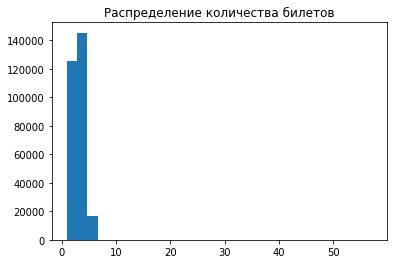

In [19]:
plt.hist(merged_df['tickets_count'], bins=30)
plt.title('Распределение количества билетов')
plt.show()

Количество билетов в заказе имеет выраженное скошенное вправо распределение: большинство заказов содержат **от 1 до 3 билетов**, **при медиане 3**. Среднее значение **(2.74)** немного ниже медианы, что подтверждает концентрацию данных в небольших заказах. При анализе методом IQR выявлено около **6%** наблюдений, выходящих за пределы типичного диапазона - это редкие крупные заказы, формирующие правый хвост распределения и не являющиеся ошибками данных, а отражающие особый сегмент пользовательского поведения.

In [20]:
display("Явные дубликаты:", df.duplicated().sum())

'Явные дубликаты:'

0

In [21]:
display("Дубликаты order_id:", df.duplicated(subset=['order_id']).sum())

'Дубликаты order_id:'

0

In [22]:
subset_cols = [
    'user_id',
    'event_id',
    'created_dt_msk',
    'tickets_count'
]

mask = df.duplicated(subset=subset_cols, keep=False)

potential_dups = df[mask].sort_values(subset_cols)

display("Потенциальные неявные дубликаты:", potential_dups.shape[0])
display(potential_dups.head(15))

'Потенциальные неявные дубликаты:'

86455

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11,6818249,000cf0659a9f40f,2024-06-20,2024-06-20 10:49:48,516728,нет,12,rub,mobile,710.95,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
16,6818104,000cf0659a9f40f,2024-06-20,2024-06-20 12:46:11,516728,нет,12,rub,mobile,710.95,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
12,6818220,000cf0659a9f40f,2024-06-20,2024-06-20 10:56:16,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
13,6818075,000cf0659a9f40f,2024-06-20,2024-06-20 12:42:12,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
14,6818191,000cf0659a9f40f,2024-06-20,2024-06-20 10:51:10,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
15,6818046,000cf0659a9f40f,2024-06-20,2024-06-20 12:40:27,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
17,6817959,000cf0659a9f40f,2024-06-21,2024-06-21 04:33:56,516728,нет,12,rub,mobile,1066.43,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
19,6759611,000cf0659a9f40f,2024-06-21,2024-06-21 04:35:38,516728,нет,12,rub,mobile,1066.43,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"
20,6818162,000cf0659a9f40f,2024-06-21,2024-06-21 04:18:44,516728,нет,12,rub,mobile,1066.43,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,широковская область,радужнополье,35.0,4471.0,"киновидеостудия ""тон"" и партнеры","ул. тихая, д. 69 стр. 669"


In [23]:
df.loc[mask, 'order_id'].nunique()

86455

При анализе неявных дубликатов было выявлено большое количество повторяющихся комбинаций пользовательских и событийных признаков. Однако проверка показала, что все эти записи соответствуют разным заказам (разные order_id), что подтверждает отсутствие дублирования данных.

Таким образом, выявленные совпадения отражают повторные покупки и активность пользователей, а не ошибки в данных.

In [24]:
# Выручка с продажи одного билета на мероприятие
merged_df['one_ticket_revenue_rub'] = (
   merged_df['revenue_rub'] / merged_df['tickets_count']
)

In [25]:
merged_df[['tickets_count', 'revenue_rub', 'one_ticket_revenue_rub']].head()

,tickets_count,revenue_rub,one_ticket_revenue_rub
0,4,1521.94,380.4850
1,2,289.45,144.7250
2,4,1258.57,314.6425
3,2,8.49,4.2450
4,3,1390.41,463.4700


In [26]:
#Месяц оформления заказа
merged_df['month'] = merged_df['created_dt_msk'].dt.month
 

In [27]:
#Сезонные категории
conditions = [
    merged_df['month'].isin([12, 1, 2]),# зима: декабрь, январь, февраль
    merged_df['month'].isin([3, 4, 5]),# весна: март, апрель, май
    merged_df['month'].isin([6, 7, 8]),# лето: июнь, июль, август
    merged_df['month'].isin([9, 10, 11])# осень: сентябрь, октябрь, ноябрь
]

choices = ['зима', 'весна', 'лето', 'осень']

merged_df['season'] = np.select(conditions, choices, default=np.nan)


In [28]:
merged_df['season'].value_counts()

осень    168646
лето     119136
Name: season, dtype: int64

In [29]:
merged_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,data,kurs_per_tenge,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213.0,3972.0,"сценический центр ""деталь"" групп","алл. машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213.0,2941.0,"музыкальная школа для детей ""аккаунт"" лтд","алл. шмидта, д. 9 стр. 4",2024-07-23,0.183419,289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"училище искусств ""нирвана"" инк","алл. юбилейная, д. 5/6",2024-10-06,0.196475,1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2.0,3574.0,"театр альтернативного искусства ""ода"" лимитед","алл. есенина, д. 243 к. 3/8",2024-07-13,0.185010,8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"театр кукол ""огни"" инкорпорэйтед","ш. набережное, д. 595 стр. 8",2024-10-04,0.196648,1390.41,463.4700,10,осень


Были созданы временные признаки: месяц оформления заказа и сезон. Месяц был извлечён из даты заказа, а сезонность определена на основе календарного деления года на зимний, весенний, летний и осенний периоды с использованием векторных операций для повышения эффективности обработки данных.

# Шаг 3. Исследовательский анализ данных:
 **3.1 Анализ распределения заказов по сегментам и их сезонные изменения**

In [30]:
# Узнаем кол-во заказов в каждом месяце 
monthly_orders = merged_df.groupby('month').size().reset_index(name='orders_count') 
display(monthly_orders)

,month,orders_count
0,6,34171
1,7,40408
2,8,44557
3,9,69355
4,10,99291


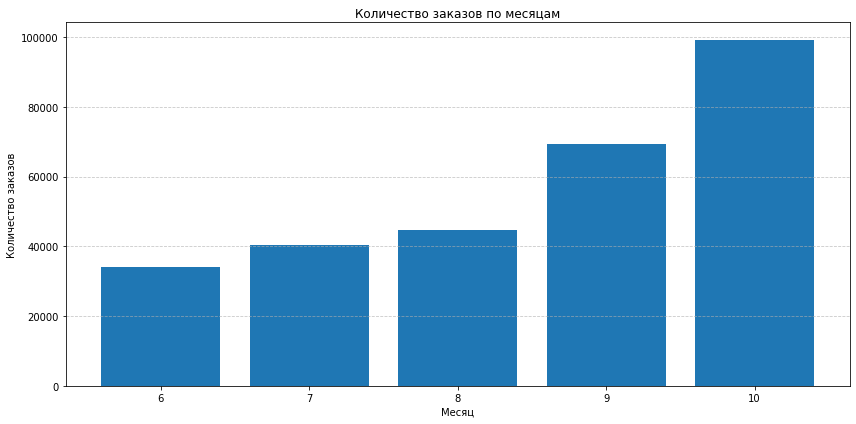

In [31]:
plt.figure(figsize=(12,6))
plt.bar(monthly_orders['month'].astype(str), monthly_orders['orders_count'])
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Количество заказов стабильно увеличивается с июня по октябрь 2024 года. Наиболее заметный рост наблюдается в сентябре и октябре, что может указывать на сезонное повышение спроса или рост активности пользователей.

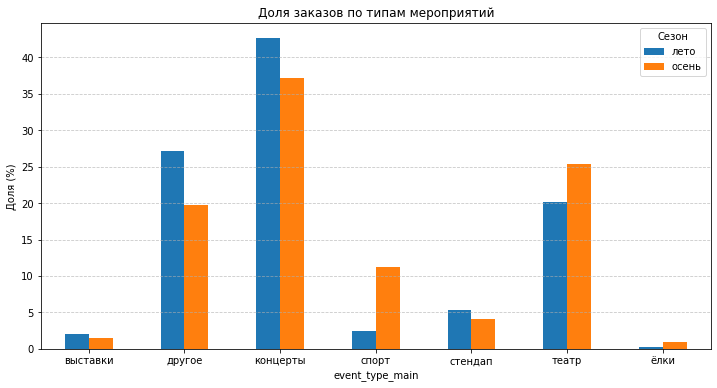

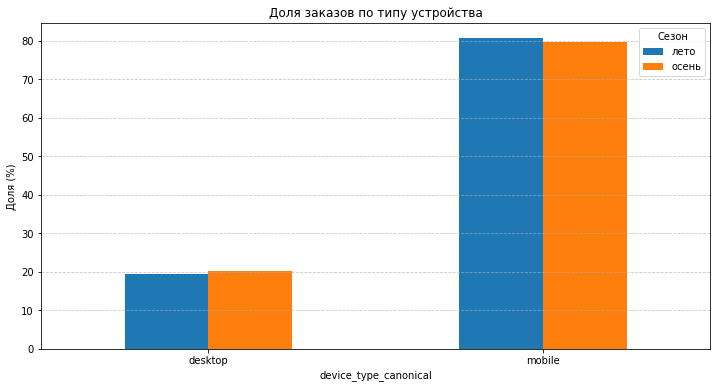

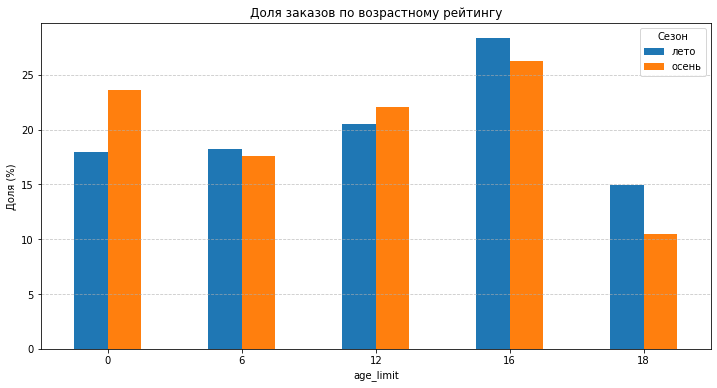

season,лето,осень
age_limit,,
0,17.969380,23.619890
6,18.194333,17.625084
12,20.535355,22.097767
16,28.334844,26.219418
18,14.966089,10.437840


In [32]:
# Создаём признак сезона на основе месяца
season_map = {6: 'лето', 7: 'лето', 8: 'лето'}

merged_df['season_period'] = merged_df['month'].map(season_map).fillna('осень')

# Функция для построения распределения заказов по сезонам 
def plot_season_dists(df, col, title):
    share_table = pd.crosstab(df[col], df['season'], normalize='columns') * 100
    # порядок сезонов
    share_table = share_table.reindex(columns=['лето', 'осень'])
    plot_ax = share_table.plot(kind='bar', figsize=(12,6))

    plt.title(title)
    plt.ylabel('Доля (%)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Сезон')

    plt.show()

    return share_table
 
plot_season_dists(merged_df,'event_type_main', 'Доля заказов по типам мероприятий')
plot_season_dists(merged_df,'device_type_canonical', 'Доля заказов по типу устройства')
plot_season_dists(merged_df,'age_limit', 'Доля заказов по возрастному рейтингу')

Сезонность заметно влияет на предпочтения. Летом выше спрос на **концерты + 10%, "другое" + 6%** и немного выигрывает в таких мероприятиях, как выставки и стендап. Осенью увеличивается спрос на **спорт около +10% и театр + 6%.**

Структура по устройствам остаётся стабильной, без выраженных сезонных изменений. 

По возрастным группам наблюдаются различия: у младших категорий доля заказов выше осенью, тогда как у 16–18 лет летом.


In [33]:
# Средняя выручка за билет по типу мероприятия и сезону
avg_revenue = (
    merged_df
    .groupby(['event_type_main', 'season'])['revenue']
    .mean()
    .reset_index(name='avg_revenue')
)

revenue_pivot = avg_revenue.pivot(
    index='event_type_main',
    columns='season',
    values='avg_revenue'
)
# Убираем строки, где нет данных хотя бы в одном сезоне
revenue_pivot = revenue_pivot.dropna()

# Расчёт относительного изменения (осень vs лето)
revenue_pivot['change_pct'] = (
    (revenue_pivot['осень'] - revenue_pivot['лето'])/ revenue_pivot['лето'] * 100
)

# Сортируем по изменению для наглядности графика
revenue_pivot = revenue_pivot.sort_values('change_pct')

display(revenue_pivot)

season,лето,осень,change_pct
event_type_main,,,
концерты,1136.990053,733.690500,-35.470808
театр,585.031798,482.811133,-17.472668
ёлки,806.906374,733.568876,-9.088724
другое,241.503380,237.045665,-1.845819
спорт,159.871633,165.091564,3.265076
выставки,228.311671,235.990866,3.363470
стендап,648.493382,677.630831,4.493099


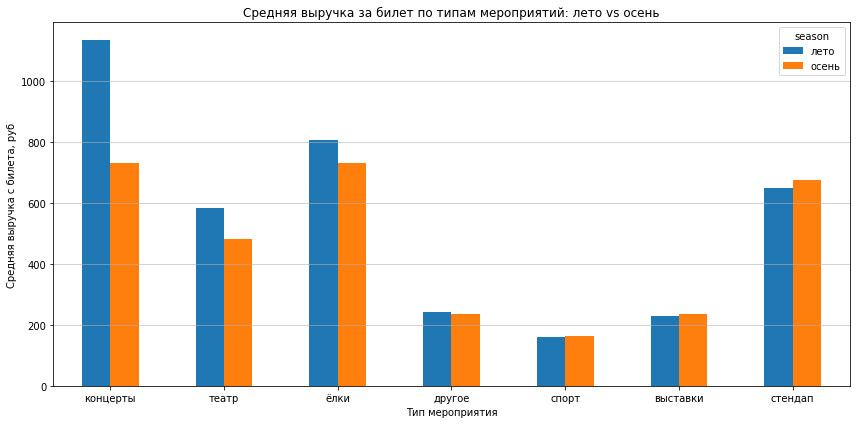

In [34]:
revenue_pivot[['лето', 'осень']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Средняя выручка за билет по типам мероприятий: лето vs осень')
plt.ylabel('Средняя выручка с билета, руб')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()

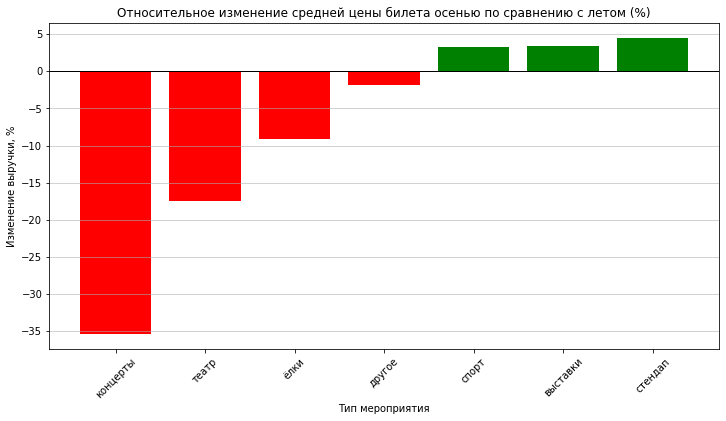

In [35]:
plt.figure(figsize=(12,6))
colors = ['red' if x < 0 else 'green' for x in revenue_pivot['change_pct']]
plt.bar(revenue_pivot.index, revenue_pivot['change_pct'], color=colors)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение выручки, %')
plt.title('Относительное изменение средней цены билета осенью по сравнению с летом (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.7)

plt.tight_layout
plt.show()

**Наибольший рост** показали **стендап (+4.49%)**, **выставки (+3.36%) и спорт (+3.26%)**, что может говорить о повышении интереса к более доступным и регулярным форматам досуга в осенний период.
**Снижение выручки** наблюдается в категориях **театр (-17.47%)** и особенно **концерты (-35.47%)**, что может быть связано с сезонностью: летом аудитория чаще посещает крупные мероприятия и концерты, а осенью спрос смещается в сторону более локальных форматов.

**3.2 Осенняя активность пользователей**

In [36]:
# Фильтруем данные только за осень 2024
df_autumn = merged_df[
    merged_df['season'] == 'осень'].copy()

# Сортируем по дате
df_autumn.sort_values('created_dt_msk', inplace=True)

# Группируем по дням и считаем ключевые метрики
daily_activity = df_autumn.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),  # общее число заказов
    unique_users=('user_id', 'nunique'),  # кол-во активных пользователей DAU
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')  # средняя стоимость билета
).reset_index()

# Считаем среднее число заказов на пользователя
daily_activity['orders_per_user'] = daily_activity['total_orders'] / daily_activity['unique_users']

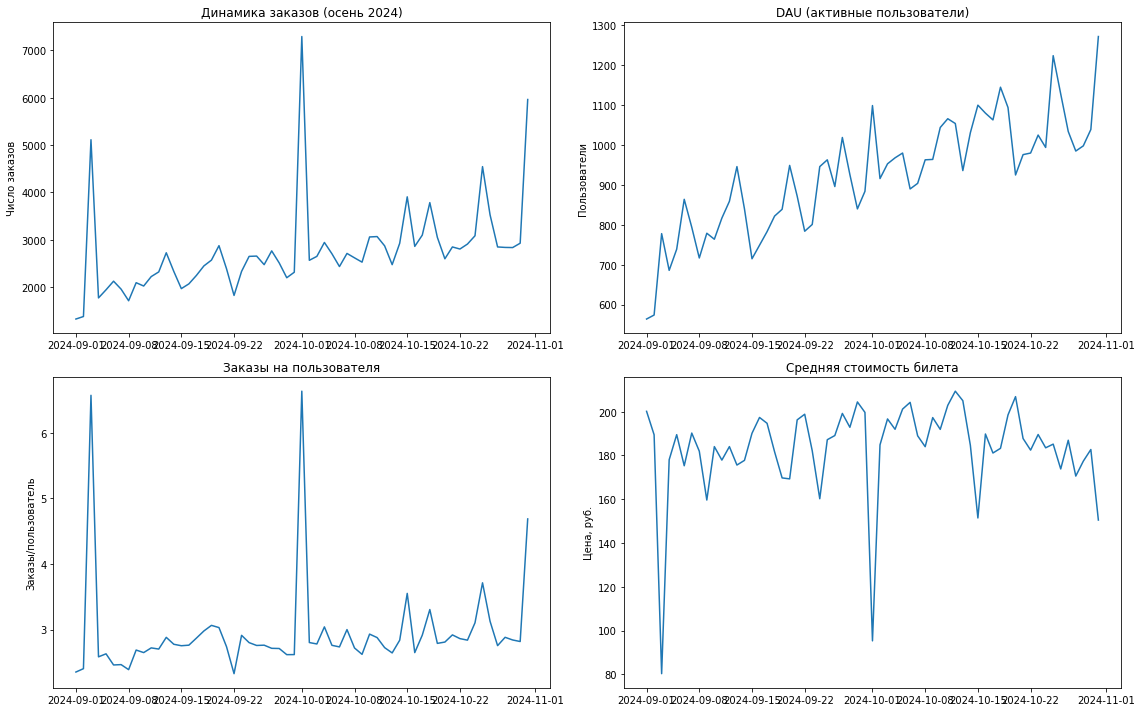

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Динамика заказов (осень 2024)
axes[0, 0].plot(daily_activity['created_dt_msk'], daily_activity['total_orders'])
axes[0, 0].set_title('Динамика заказов (осень 2024)')
axes[0, 0].set_ylabel('Число заказов')

# DAU (кол-во активных пользователей)
axes[0, 1].plot(daily_activity['created_dt_msk'], daily_activity['unique_users'])
axes[0, 1].set_title('DAU (активные пользователи)')
axes[0, 1].set_ylabel('Пользователи')

# Среднее число заказов на пользователя
axes[1, 0].plot(daily_activity['created_dt_msk'], daily_activity['orders_per_user'])
axes[1, 0].set_title('Заказы на пользователя')
axes[1, 0].set_ylabel('Заказы/пользователь')

# Средняя стоимость одного билета
axes[1, 1].plot(daily_activity['created_dt_msk'], daily_activity['avg_ticket_price'])
axes[1, 1].set_title('Средняя стоимость билета')
axes[1, 1].set_ylabel('Цена, руб.')

plt.tight_layout()
plt.show()


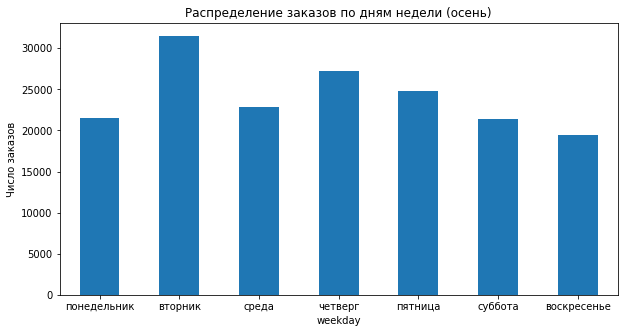

В будни в среднем за день: 25582 заказов, в выходные: 20368 заказов


In [38]:
# Недельная цикличность
df_autumn['weekday'] = df_autumn['created_dt_msk'].dt.dayofweek  # 0=пн
weekday_orders = df_autumn.groupby('weekday')['order_id'].count()
weekday_names = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
plt.figure(figsize=(10,5))
weekday_orders.plot(kind='bar')
plt.xticks(range(7), weekday_names, rotation=0)
plt.title('Распределение заказов по дням недели (осень)')
plt.ylabel('Число заказов')
plt.show()

weekday_avg = df_autumn[df_autumn['weekday'] < 5]['order_id'].count() / 5
weekend_avg = df_autumn[df_autumn['weekday'] >= 5]['order_id'].count() / 2
print(f"В будни в среднем за день: {weekday_avg:.0f} заказов, в выходные: {weekend_avg:.0f} заказов")

**Вывод**
1. Динамика заказов осенью 2024 года - импульсная: на фоне базового уровня **2000–4000** заказов происходят резкие всплески (**до 7000**), вероятно, из‑за внешних событий, а так же возможно из за проведения акций в эти дни.
2. На графике DAU (активные пользователи) прослеживается постепенный рост числа пользователей с **~ 600 в начале сентября до свыше 1250 к 31 октября 2024 года.**
3. На графике - эпизодические всплески заказов на пользователя **(до ~ 6,5)** на фоне стабильного уровня **2,5–3,5;** к концу октября — тенденция к росту.
4. Аномальные провалы средней стоимости билета **(до 80–100 рублей)** совпадают по времени с всплесками заказов на пользователя - это может указывать на проведение акций или распродаж. При этом кратковременные пики цены **(до ~ 210 рублей)** вероятно связаны с повышенным спросом в отдельные дни либо с изменением структуры продаж (например, ростом доли более дорогих билетов).
5. Наблюдается выраженная разница в объёме заказов между буднями и выходными: в будни в среднем фиксируется на **~ 5200** заказов больше, чем в выходные. 

**3.3 Популярные события и партнёры**

In [39]:
# Группируем по регионам
region_stats = (
    merged_df.groupby('region_name')
    .agg(
        unique_events=('event_id', 'nunique'),
        total_orders=('order_id', 'count'),
        total_revenue=('revenue_rub', 'sum')
    )
    .reset_index()
)
# Считаем доли
total_events = merged_df['event_id'].nunique()
total_orders = merged_df['order_id'].count()
total_revenue = merged_df['revenue_rub'].sum()

region_stats['share_events'] = (region_stats['unique_events'] / total_events * 100).round(2)
region_stats['share_orders'] = (region_stats['total_orders'] / total_orders * 100).round(2)
region_stats['share_revenue'] = (region_stats['total_revenue'] / total_revenue * 100).round(2)

# Сортируем по числу заказов 
region_stats = region_stats.sort_values('total_orders', ascending=False)


print("\nТоп-10 регионов по числу заказов:")
region_stats.head(10)


Топ-10 регионов по числу заказов:


,region_name,unique_events,total_orders,total_revenue,share_events,share_orders,share_revenue
23,каменевский регион,5935,89674,5.591789e+07,26.54,31.16,37.46
60,североярская область,3800,43745,2.210624e+07,17.00,15.20,14.81
77,широковская область,1232,16169,8.628101e+06,5.51,5.62,5.78
42,медовская область,504,13895,2.928079e+06,2.25,4.83,1.96
45,озернинский край,349,10405,9.554058e+06,1.56,3.62,6.40
57,светополянский округ,1075,7503,3.039749e+06,4.81,2.61,2.04
41,малиновоярский округ,165,6314,5.089834e+06,0.74,2.19,3.41
64,солнечноземская область,522,6279,1.180990e+06,2.33,2.18,0.79
52,речиновская область,702,6267,2.630315e+06,3.14,2.18,1.76
78,яблоневская область,535,6125,3.505729e+06,2.39,2.13,2.35


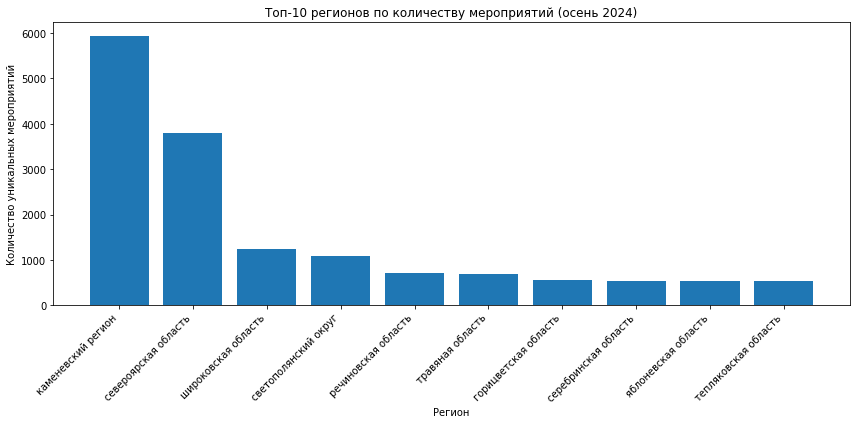

In [40]:
top_regions = region_stats.nlargest(10, 'unique_events')

plt.figure(figsize=(12, 6))
bars = plt.bar(
    top_regions['region_name'],
    top_regions['unique_events']
)

plt.title('Топ-10 регионов по количеству мероприятий (осень 2024)')
plt.xlabel('Регион')
plt.ylabel('Количество уникальных мероприятий')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [41]:
# Группируем по партнерам и считаем метрики
partner_analysis = (
    df_autumn.groupby('service_name')
    .agg(
        unique_events=('event_id', 'nunique'),
        total_orders=('order_id', 'count'),
        total_revenue=('revenue_rub', 'sum')
    )
    .reset_index()
)
# Общие показатели для долей
total_events = df_autumn['event_id'].nunique()
total_orders = df_autumn['order_id'].count()
total_revenue = df_autumn['revenue_rub'].sum()

# Доли
partner_analysis['events_share'] = (partner_analysis['unique_events'] / total_events * 100).round(2)
partner_analysis['orders_share'] = (partner_analysis['total_orders'] / total_orders * 100).round(2)
partner_analysis['revenue_share'] = (partner_analysis['total_revenue'] / total_revenue * 100).round(2)

# Сортируем по выручке
partner_analysis = partner_analysis.sort_values('total_revenue',ascending=False)

print("\nТоп-10 партнёров по выручке:")
partner_analysis.head(10)



Топ-10 партнёров по выручке:


,service_name,unique_events,total_orders,total_revenue,events_share,orders_share,revenue_share
3,билеты без проблем,2847,32409,1.217370e+07,17.93,19.22,14.87
24,мой билет,1005,19418,1.085178e+07,6.33,11.51,13.25
25,облачко,1409,15478,1.061105e+07,8.88,9.18,12.96
21,лови билет!,3616,25797,1.038224e+07,22.78,15.30,12.68
8,весь в билетах,599,9416,9.351279e+06,3.77,5.58,11.42
5,билеты в руки,2469,25731,7.613812e+06,15.55,15.26,9.30
19,край билетов,193,2997,3.018373e+06,1.22,1.78,3.69
34,яблоко,537,3473,2.763332e+06,3.38,2.06,3.37
26,прачечная,728,5798,2.548310e+06,4.59,3.44,3.11
30,тебе билет!,859,3760,2.166179e+06,5.41,2.23,2.65


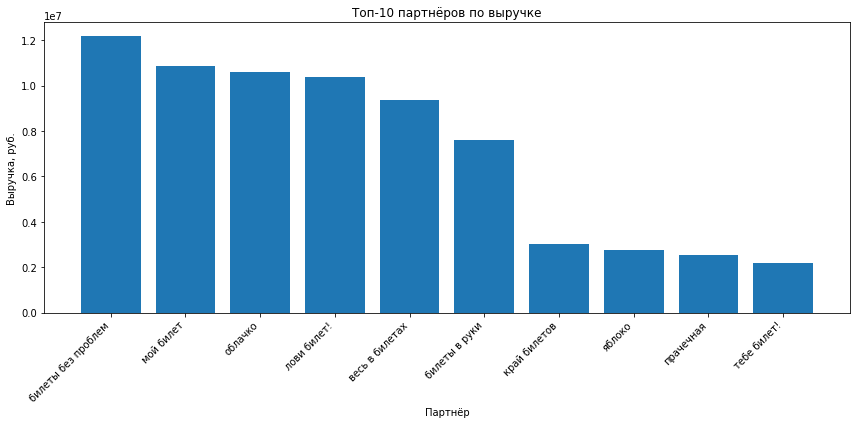

In [42]:
# Топ-10 партнеров по выручке
top_partners = partner_analysis.sort_values(
    'total_revenue',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_partners['service_name'],
    top_partners['total_revenue']
)

plt.title('Топ-10 партнёров по выручке')
plt.xlabel('Партнёр')
plt.ylabel('Выручка, руб.')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Ключевыми регионами по разнообразию мероприятий и активности являются Каменевский регион и Североярская область.

* Каменевский регион - безусловный лидер рынка. На него приходится **26,54% всех мероприятий и 31,16% заказов**, что делает его главным драйвером платформы. Регион сочетает высокий уровень событийной активности и сильный пользовательский спрос, что указывает на развитую инфраструктуру и высокую вовлечённость аудитории. Это основной регион роста и масштабирования.
* Североярская область - второй по значимости регион.**17% мероприятий и 15,2% заказов.** При этом наблюдается небольшой дисбаланс: событий больше, чем спроса, что может указывать на потенциал для улучшения маркетинга или повышения конверсии.
* Концентрация рынка высокая: **два региона формируют около 48% мероприятий и 46% заказов**, что говорит о заметной географической концентрации спроса.

Рынок билетных сервисов показывает умеренную концентрацию: несколько крупных игроков формируют основную долю выручки.
* Лидером по выручке является **«Билеты без проблем» — сервис обеспечивает 16,3% общей выручки**, оставаясь ключевым драйвером монетизации на платформе при высокой операционной активности.
* Второе место занимает **«Мой билет» с долей 14,8% выручки**. Несмотря на более скромный объём мероприятий, сервис демонстрирует высокую эффективность монетизации и стабильный поток заказов.
* **«Облачко» и «Лови билет!»** формируют сопоставимую долю рынка **(12,5% и 11,2% выручки соответственно)**, но при этом различаются по структуре, «Лови билет!» лидирует по числу мероприятий, но уступает по конверсии в выручку.
* Остальные сервисы («Весь в билетах», «Билеты в руки» и др.) формируют длинный хвост рынка, каждый из них занимает менее 10% выручки.

**Общий вывод**
Лидеры по разным метрикам не совпадают:
* по мероприятиям лидирует «Лови билет!»
* по выручке — «Билеты без проблем»
* по эффективности — «Мой билет»
Рынок умеренно концентрирован: топ-3 партнёра формируют около 46% всей выручки, что указывает на значимую, но не критическую зависимость от лидеров.


# Шаг 4. Статистический анализ данных #

1. Гипотеза. Среднее количество заказов на пользователя

- Нулевая гипотеза H₀: среднее количество заказов на одного пользователя мобильного приложения не выше, чем у пользователей стационарных устройств.

- Альтернативная гипотеза H₁: среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств.



2. Гипотеза. Среднее время между заказами  

- Нулевая гипотеза H₀: среднее время между заказами пользователей мобильных приложений не выше, чем у пользователей стационарных устройств.

- Альтернативная гипотеза H₁: среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств.

In [43]:
# Гипотеза 1: среднее количество заказов на пользователя
user_orders = (
    df_autumn
    .groupby(['device_type_canonical', 'user_id'])
    .size()
    .reset_index(name='total_orders_per_user')
)

orders_per_user = user_orders.groupby('device_type_canonical')['total_orders_per_user'].mean()

print("Средние значения по группам:")
print(orders_per_user)

mobile_data = user_orders[
    user_orders['device_type_canonical'] == 'mobile'
]['total_orders_per_user']

desktop_data = user_orders[
    user_orders['device_type_canonical'] == 'desktop'
]['total_orders_per_user']


t_stat, p_value = stats.ttest_ind(
    mobile_data,
    desktop_data,
    alternative='greater',
    equal_var=False  
)

p_value_print = "<0.0001" if p_value < 0.0001 else f"{p_value:.4f}"

print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-значение: {p_value_print}")


alpha = 0.05

print("\nВывод:")

if p_value < alpha:
    print("Отвергаем H₀.")
    print("Мобильные пользователи совершают статистически значимо больше заказов на пользователя.")
else:
    print("Не отвергаем H₀.")
    print("Статистически значимых различий не обнаружено.")


Средние значения по группам:
device_type_canonical
desktop    7.047658
mobile     9.465755
Name: total_orders_per_user, dtype: float64

t-статистика: 3.1415
p-значение: 0.0008

Вывод:
Отвергаем H₀.
Мобильные пользователи совершают статистически значимо больше заказов на пользователя.


* Мобильные пользователи совершают примерно на 34% больше заказов, что указывает на более высокую активность по сравнению с десктопной аудиторией:
- Мобильные пользователи: 9,46 заказа на пользователя
- Десктопные пользователи: 7,04 заказа на пользователя

Результаты статистического теста:
- t-статистика = 3,14
- p-value = 0,0008

Положительное значение t-статистики подтверждает, что среднее число заказов у мобильных пользователей выше. Очень низкое p-value (0,0008) говорит о том, что вероятность случайного появления такой разницы крайне мала.

Мобильный канал демонстрирует более высокую частоту покупок, что может указывать на:
- более удобный пользовательский опыт в приложении;
- импульсный характер покупок с мобильных устройств;
- более высокую вовлечённость мобильной аудитории.

In [44]:
# Гипотеза 2: время между заказами
mobile_gap = df_autumn.loc[
    df_autumn['device_type_canonical'] == 'mobile',
    'days_since_prev'
].dropna()

desktop_gap = df_autumn.loc[
    df_autumn['device_type_canonical'] == 'desktop',
    'days_since_prev'
].dropna()

print("\nСреднее время между заказами:")
print(f"Mobile:  {mobile_gap.mean():.2f}")
print(f"Desktop: {desktop_gap.mean():.2f}")

# Mann–Whitney U test (распределение обычно не нормальное)
stat2, p2 = stats.mannwhitneyu(
    mobile_gap,
    desktop_gap,
    alternative='greater'
)

p2_print = "<0.0001" if p2 < 0.0001 else f"{p2:.4f}"

print(f"\np-value: {p2_print}")

alpha = 0.05

print("\nВывод:")

if p2 < alpha:
    print("Отвергаем H₀.")
    print("У мобильных пользователей статистически больше время между заказами.")
else:
    print("Не отвергаем H₀.")
    print("Статистически значимых различий не обнаружено.")


Среднее время между заказами:
Mobile:  3.78
Desktop: 3.02

p-value: <0.0001

Вывод:
Отвергаем H₀.
У мобильных пользователей статистически больше время между заказами.


Мобильные пользователи имеют большее среднее время между заказами (3.78) по сравнению с десктопными (3.02). Результат статистически значим (p-value < 0.0001), поэтому нулевая гипотеза отвергается. Это означает, что мобильные пользователи совершают покупки реже по времени, чем пользователи десктопных устройств.


# Выводы #

**Информация о данных**
Анализ проведен на основе данных Яндекс Афиша за период 01.06.2024–31.10.2024 (5 месяцев). Детально был рассмотрен осенний период. В данных содержится информация, о заказах билетов на мероприятия, типах устройств пользователей, стоимости билетов, категориях мероприятий, партнерах-организаторах мероприятий и регионах.

**Основные результаты**
* Сезонность: рост заказов с июня (34 171) до октября (99 291). Осенью смещается структура спроса: доля театра растёт с 20% до 26%, концертов снижается на ~10%, спорт увеличивается на 10%
* Выручка на билет: рост у выставок (+3,36%) и стендапа (+4,49%), снижение у театра (−17,47%) и особенно у концертов (−35,47%).
* Активность по дням недели: будни — 25 582 заказов, выходные — 20 368. Заказы в будни выше.
* Регионы-лидеры по заказам: Каменевский (31,16%), Североярская (15,2%), Широковская (5,62%) — более 50% всех заказов.
* Партнёры: «Билеты без проблем» (14,87%), «Мой билет» (13,25%), «Облачко» (12,96%), «Лови билет» (12,68%) — топ-4 дают >50% выручки.

**Проверка гипотез**
* H1 (мобильные активнее): подтверждена (p < 0.001). Мобильные: 9,46 заказа на пользователя, десктоп: 7,04.
* H2 (интервал между заказами выше у мобильных): подтверждена (p < 0.001). Мобильные: 3,78 дня, десктоп: 3,02 дня.
Мобильные пользователи более активны по количеству заказов, но делают их с более длинным интервалом.

**Рекомендации**
1. Усилить мобильную платформу — основной драйвер заказов.
2. Стимулировать продажи в будни через акции и персональные предложения.
3. Оптимизировать театральный сегмент: рост доли при падении выручки на билет.
4. Развивать регионы за пределами топ-3 через локальные партнёрства.
5. Снизить зависимость от ключевых партнёров за счёт расширения партнёрской базы
6. Исследовать поведение мобильных пользователей с длинным интервалом между заказами.
